# **Salient Object Detection**

# Import libraries

In [40]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.transforms.functional as TF

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


# Data setup

In [1]:
import os

BASE_DIR = "/content/sod_project"

IMAGE_DIR = os.path.join(BASE_DIR, "dataset/images")
MASK_DIR = os.path.join(BASE_DIR, "dataset/masks")
CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

for folder in [IMAGE_DIR, MASK_DIR, CHECKPOINT_DIR, RESULTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Project folders created:")
print(BASE_DIR)

Project folders created:
/content/sod_project


# ECSSD

In [2]:
from google.colab import files
uploaded = files.upload()

Saving images.zip to images.zip
Saving ground_truth_mask.zip to ground_truth_mask.zip


# Download and Extraction

In [3]:
import zipfile

for file_name in uploaded.keys():
    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall("/content/sod_project")

print("Extraction done!")

Extraction done!


In [4]:
!ls /content/sod_project

checkpoints  dataset  ground_truth_mask  images  results


In [5]:
!ls /content/sod_project/*

/content/sod_project/checkpoints:

/content/sod_project/dataset:
images	masks

/content/sod_project/ground_truth_mask:
0001.png  0126.png  0251.png  0376.png	0501.png  0626.png  0751.png  0876.png
0002.png  0127.png  0252.png  0377.png	0502.png  0627.png  0752.png  0877.png
0003.png  0128.png  0253.png  0378.png	0503.png  0628.png  0753.png  0878.png
0004.png  0129.png  0254.png  0379.png	0504.png  0629.png  0754.png  0879.png
0005.png  0130.png  0255.png  0380.png	0505.png  0630.png  0755.png  0880.png
0006.png  0131.png  0256.png  0381.png	0506.png  0631.png  0756.png  0881.png
0007.png  0132.png  0257.png  0382.png	0507.png  0632.png  0757.png  0882.png
0008.png  0133.png  0258.png  0383.png	0508.png  0633.png  0758.png  0883.png
0009.png  0134.png  0259.png  0384.png	0509.png  0634.png  0759.png  0884.png
0010.png  0135.png  0260.png  0385.png	0510.png  0635.png  0760.png  0885.png
0011.png  0136.png  0261.png  0386.png	0511.png  0636.png  0761.png  0886.png
0012.png  0137.png  026

# Data Organization

In [6]:
import shutil
import os

src_images = "/content/sod_project/images"
src_masks = "/content/sod_project/ground_truth_mask"

dst_images = "/content/sod_project/dataset/images"
dst_masks = "/content/sod_project/dataset/masks"


for file in os.listdir(src_images):
    shutil.move(os.path.join(src_images, file), os.path.join(dst_images, file))


for file in os.listdir(src_masks):
    shutil.move(os.path.join(src_masks, file), os.path.join(dst_masks, file))

print("Files moved successfully!")

Files moved successfully!


In [7]:
!ls /content/sod_project/dataset/images | head

0001.jpg
0002.jpg
0003.jpg
0004.jpg
0005.jpg
0006.jpg
0007.jpg
0008.jpg
0009.jpg
0010.jpg


In [8]:
!ls /content/sod_project/dataset/masks | head

0001.png
0002.png
0003.png
0004.png
0005.png
0006.png
0007.png
0008.png
0009.png
0010.png


# PyTorch Dataset

In [9]:
import os
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as T
import random

class SODDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=True):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.images = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_name = img_name.replace('.jpg', '.png')  # important
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            # Resize
            resize = T.Resize((224, 224))
            image = resize(image)
            mask = resize(mask)

            # Convert to tensor
            image = T.ToTensor()(image)
            mask = T.ToTensor()(mask)

        return image, mask

In [10]:
image_dir = "/content/sod_project/dataset/images"
mask_dir = "/content/sod_project/dataset/masks"

dataset = SODDataset(image_dir, mask_dir)

print("Dataset size:", len(dataset))

img, mask = dataset[0]

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)

Dataset size: 1000
Image shape: torch.Size([3, 224, 224])
Mask shape: torch.Size([1, 224, 224])


# Visualization

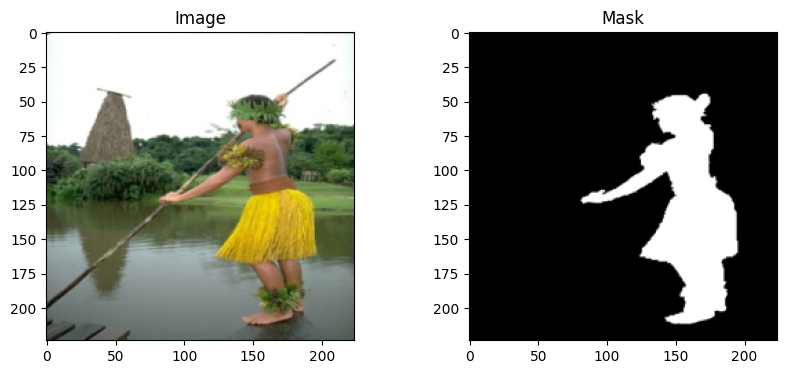

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask.squeeze(), cmap='gray')

plt.show()

# Split dataset

In [12]:
from torch.utils.data import random_split

dataset_size = len(dataset)

train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 700
Val: 150
Test: 150


# Dataloader

In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [14]:
images, masks = next(iter(train_loader))

print("Batch images:", images.shape)
print("Batch masks:", masks.shape)

Batch images: torch.Size([8, 3, 224, 224])
Batch masks: torch.Size([8, 1, 224, 224])


# Model Architecture

In [15]:
import torch
import torch.nn as nn

class SODModel(nn.Module):
    def __init__(self):
        super(SODModel, self).__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.ReLU()
        )

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ReLU()
        )

        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU()
        )

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)

        x = self.dec1(x)
        x = self.dec2(x)
        x = self.dec3(x)

        x = self.out(x)
        return torch.sigmoid(x)

In [16]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [17]:
model = SODModel().to(device)

sample = torch.randn(1, 3, 224, 224).to(device)
output = model(sample)

print("Output shape:", output.shape)

Output shape: torch.Size([1, 1, 224, 224])


# Loss Function

In [18]:
def iou_score(pred, target, smooth=1e-6):
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

In [19]:
import torch.nn as nn

bce_loss = nn.BCELoss()

def combined_loss(pred, target):
    bce = bce_loss(pred, target)

    iou = iou_score(pred, target)

    loss = bce + 0.5 * (1 - iou)
    return loss

In [20]:
!rm /content/sod_project/checkpoints/improved_last_checkpoint.pth
!rm /content/sod_project/checkpoints/improved_best_model.pth

rm: cannot remove '/content/sod_project/checkpoints/improved_last_checkpoint.pth': No such file or directory
rm: cannot remove '/content/sod_project/checkpoints/improved_best_model.pth': No such file or directory


In [21]:
sample_pred = torch.rand(1, 1, 224, 224)
sample_target = torch.rand(1, 1, 224, 224)

loss = combined_loss(sample_pred, sample_target)
print("Loss:", loss.item())

Loss: 1.3325068950653076


# Training Logic

In [22]:
checkpoint_path = "/content/sod_project/checkpoints/last_checkpoint.pth"
best_model_path = "/content/sod_project/checkpoints/best_model.pth"

In [46]:

import os
import torch.optim as optim

num_epochs = 15
start_epoch = 0
best_val_loss = float("inf")

optimizer = optim.Adam(model.parameters(), lr=1e-3)

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]

    print(f"Resumed training from epoch {start_epoch}")
else:
    print("No checkpoint found. Starting training from scratch.")

train_losses = []
val_losses = []

for epoch in range(start_epoch, num_epochs):
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)
        loss = combined_loss(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)
            loss = combined_loss(preds, masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_val_loss": best_val_loss
    }, checkpoint_path)

    print("Checkpoint saved.")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")

No checkpoint found. Starting training from scratch.
Epoch 1/15 | Train Loss: 0.8485 | Val Loss: 0.8484
Checkpoint saved.
Best model saved.
Epoch 2/15 | Train Loss: 0.8470 | Val Loss: 0.8944
Checkpoint saved.
Epoch 3/15 | Train Loss: 0.8445 | Val Loss: 0.8600
Checkpoint saved.
Epoch 4/15 | Train Loss: 0.8359 | Val Loss: 0.8393
Checkpoint saved.
Best model saved.
Epoch 5/15 | Train Loss: 0.8332 | Val Loss: 0.8471
Checkpoint saved.
Epoch 6/15 | Train Loss: 0.8318 | Val Loss: 0.8378
Checkpoint saved.
Best model saved.
Epoch 7/15 | Train Loss: 0.8328 | Val Loss: 0.8561
Checkpoint saved.
Epoch 8/15 | Train Loss: 0.8357 | Val Loss: 0.8389
Checkpoint saved.
Epoch 9/15 | Train Loss: 0.8365 | Val Loss: 0.8373
Checkpoint saved.
Best model saved.
Epoch 10/15 | Train Loss: 0.8301 | Val Loss: 0.8353
Checkpoint saved.
Best model saved.
Epoch 11/15 | Train Loss: 0.8302 | Val Loss: 0.8458
Checkpoint saved.
Epoch 12/15 | Train Loss: 0.8271 | Val Loss: 0.8250
Checkpoint saved.
Best model saved.
Epoch 13

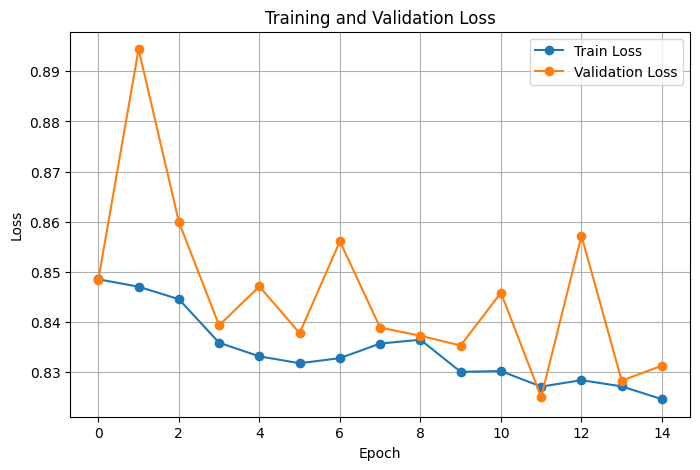

In [47]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o', label="Train Loss")
plt.plot(val_losses, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.grid(True)

plt.savefig("training_curve.png", bbox_inches='tight')

plt.show()

In [45]:
!rm /content/sod_project/checkpoints/last_checkpoint.pth

In [24]:
!ls /content/sod_project/checkpoints

best_model.pth	last_checkpoint.pth


# Evaluation

In [25]:
model = SODModel().to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [26]:
def calculate_metrics(pred, target, threshold=0.5, smooth=1e-6):
    pred = (pred > threshold).float()
    target = target.float()

    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum()

    intersection = tp
    union = pred.sum() + target.sum() - intersection

    iou = (intersection + smooth) / (union + smooth)
    precision = (tp + smooth) / (tp + fp + smooth)
    recall = (tp + smooth) / (tp + fn + smooth)
    f1 = 2 * (precision * recall) / (precision + recall + smooth)

    return iou.item(), precision.item(), recall.item(), f1.item()

In [27]:
total_iou = 0
total_precision = 0
total_recall = 0
total_f1 = 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        iou, precision, recall, f1 = calculate_metrics(preds, masks)

        total_iou += iou
        total_precision += precision
        total_recall += recall
        total_f1 += f1

num_batches = len(test_loader)

print("Test Results:")
print(f"IoU: {total_iou / num_batches:.4f}")
print(f"Precision: {total_precision / num_batches:.4f}")
print(f"Recall: {total_recall / num_batches:.4f}")
print(f"F1 Score: {total_f1 / num_batches:.4f}")

Test Results:
IoU: 0.2532
Precision: 0.5244
Recall: 0.3352
F1 Score: 0.3959


# Results and Visualization

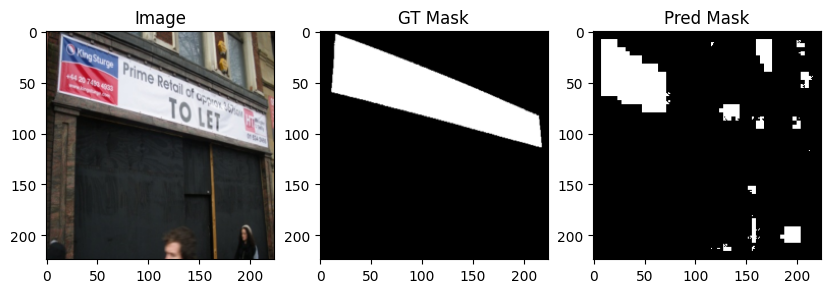

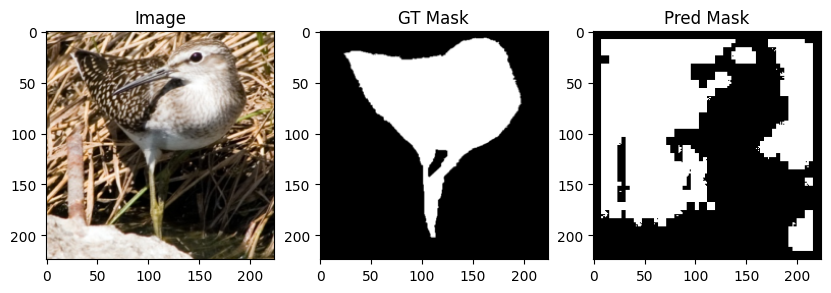

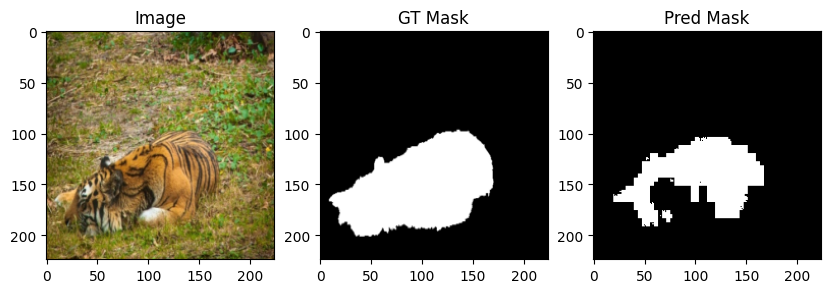

In [28]:
import matplotlib.pyplot as plt

model.eval()

images, masks = next(iter(test_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    preds = model(images)

images = images.cpu()
masks = masks.cpu()
preds = preds.cpu()

for i in range(3):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(images[i].permute(1,2,0))

    plt.subplot(1,3,2)
    plt.title("GT Mask")
    plt.imshow(masks[i].squeeze(), cmap='gray')

    plt.subplot(1,3,3)
    plt.title("Pred Mask")
    plt.imshow((preds[i].squeeze() > 0.5), cmap='gray')

    plt.show()

In [41]:
plt.savefig("predictions_baseline.png", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

# Improvements

Improved model

In [29]:
class ImprovedSODModel(nn.Module):
    def __init__(self):
        super(ImprovedSODModel, self).__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool2d(2)
        )

        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool2d(2)
        )

        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool2d(2)
        )

        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 2, stride=2),
            nn.ReLU()
        )

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU()
        )

        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU()
        )

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)

        x = self.dec1(x)
        x = self.dec2(x)
        x = self.dec3(x)

        x = self.out(x)
        return torch.sigmoid(x)

Improved model training setup

In [30]:
improved_model = ImprovedSODModel().to(device)

improved_checkpoint_path = "/content/sod_project/checkpoints/improved_last_checkpoint.pth"
improved_best_model_path = "/content/sod_project/checkpoints/improved_best_model.pth"

optimizer = optim.Adam(improved_model.parameters(), lr=1e-3)

num_epochs = 25
start_epoch = 0
best_val_loss = float("inf")

Improved training loop

In [31]:
import os

if os.path.exists(improved_checkpoint_path):
    checkpoint = torch.load(improved_checkpoint_path, map_location=device)

    improved_model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]

    print(f"Resumed improved model training from epoch {start_epoch}")
else:
    print("No improved checkpoint found. Starting improved model training from scratch.")

for epoch in range(start_epoch, num_epochs):
    improved_model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = improved_model(images)
        loss = combined_loss(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    improved_model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            preds = improved_model(images)
            loss = combined_loss(preds, masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    torch.save({
        "epoch": epoch,
        "model_state": improved_model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_val_loss": best_val_loss
    }, improved_checkpoint_path)

    print("Improved checkpoint saved.")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(improved_model.state_dict(), improved_best_model_path)
        print("Improved best model saved.")

No improved checkpoint found. Starting improved model training from scratch.
Epoch 1/25 | Train Loss: 0.8987 | Val Loss: 0.8729
Improved checkpoint saved.
Improved best model saved.
Epoch 2/25 | Train Loss: 0.8701 | Val Loss: 0.8716
Improved checkpoint saved.
Improved best model saved.
Epoch 3/25 | Train Loss: 0.8495 | Val Loss: 0.8751
Improved checkpoint saved.
Epoch 4/25 | Train Loss: 0.8501 | Val Loss: 0.8847
Improved checkpoint saved.
Epoch 5/25 | Train Loss: 0.8454 | Val Loss: 0.9663
Improved checkpoint saved.
Epoch 6/25 | Train Loss: 0.8388 | Val Loss: 0.8784
Improved checkpoint saved.
Epoch 7/25 | Train Loss: 0.8441 | Val Loss: 0.9000
Improved checkpoint saved.
Epoch 8/25 | Train Loss: 0.8396 | Val Loss: 0.8836
Improved checkpoint saved.
Epoch 9/25 | Train Loss: 0.8293 | Val Loss: 0.9348
Improved checkpoint saved.
Epoch 10/25 | Train Loss: 0.8208 | Val Loss: 0.8838
Improved checkpoint saved.
Epoch 11/25 | Train Loss: 0.8241 | Val Loss: 0.8866
Improved checkpoint saved.
Epoch 12/

Improved model evaluation

In [32]:
improved_model = ImprovedSODModel().to(device)
improved_model.load_state_dict(torch.load(improved_best_model_path, map_location=device))
improved_model.eval()

total_iou = 0
total_precision = 0
total_recall = 0
total_f1 = 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = improved_model(images)

        iou, precision, recall, f1 = calculate_metrics(preds, masks)

        total_iou += iou
        total_precision += precision
        total_recall += recall
        total_f1 += f1

num_batches = len(test_loader)

improved_iou = total_iou / num_batches
improved_precision = total_precision / num_batches
improved_recall = total_recall / num_batches
improved_f1 = total_f1 / num_batches

print("Improved Test Results:")
print(f"IoU: {improved_iou:.4f}")
print(f"Precision: {improved_precision:.4f}")
print(f"Recall: {improved_recall:.4f}")
print(f"F1 Score: {improved_f1:.4f}")

Improved Test Results:
IoU: 0.1329
Precision: 0.5707
Recall: 0.1496
F1 Score: 0.2244


Compare baseline and improved

In [33]:
baseline_iou = 0.3000
baseline_precision = 0.5250
baseline_recall = 0.4212
baseline_f1 = 0.4572

print("Comparison Table")
print("---------------------------------------------")
print("Model       IoU     Precision   Recall   F1")
print("---------------------------------------------")
print(f"Baseline    {baseline_iou:.4f}  {baseline_precision:.4f}     {baseline_recall:.4f}   {baseline_f1:.4f}")
print(f"Improved    {improved_iou:.4f}  {improved_precision:.4f}     {improved_recall:.4f}   {improved_f1:.4f}")

Comparison Table
---------------------------------------------
Model       IoU     Precision   Recall   F1
---------------------------------------------
Baseline    0.3000  0.5250     0.4212   0.4572
Improved    0.1329  0.5707     0.1496   0.2244


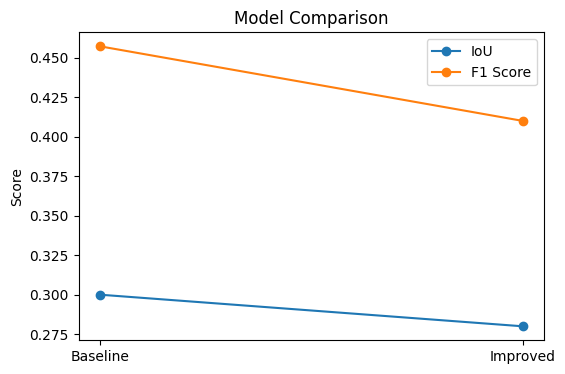

In [44]:
import matplotlib.pyplot as plt

models = ["Baseline", "Improved"]

iou_scores = [0.30, 0.28]
f1_scores = [0.4572, 0.41]

x = range(len(models))

plt.figure(figsize=(6,4))

plt.plot(x, iou_scores, marker='o', label="IoU")
plt.plot(x, f1_scores, marker='o', label="F1 Score")

plt.xticks(x, models)

plt.ylabel("Score")
plt.title("Model Comparison")

plt.legend()

plt.savefig("comparison_chart.png", bbox_inches='tight')

plt.show()

Improved Visualization

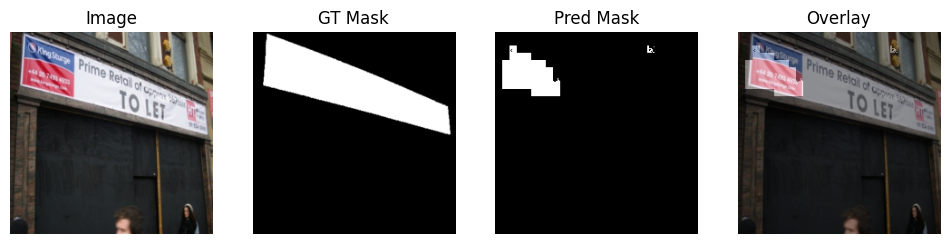

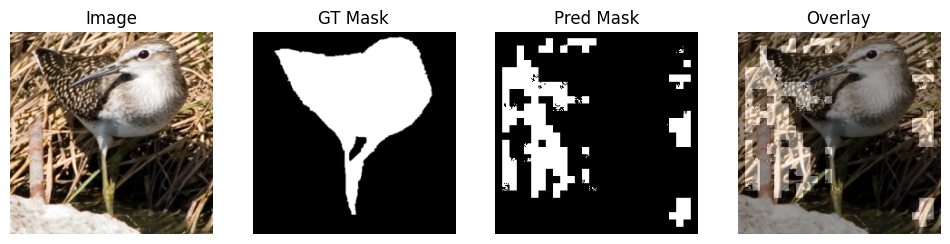

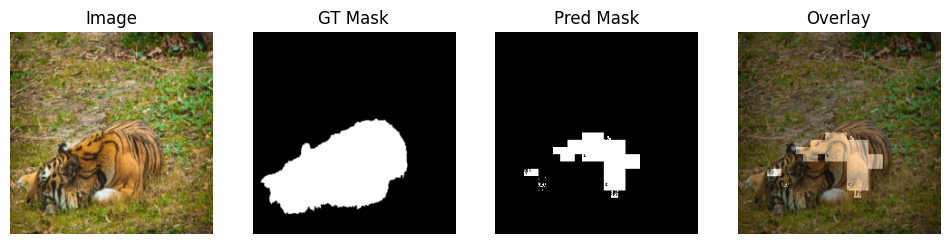

In [34]:
import matplotlib.pyplot as plt

improved_model.eval()

images, masks = next(iter(test_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    preds = improved_model(images)

images = images.cpu()
masks = masks.cpu()
preds = preds.cpu()

for i in range(3):
    plt.figure(figsize=(12, 3))

    plt.subplot(1, 4, 1)
    plt.title("Image")
    plt.imshow(images[i].permute(1, 2, 0))
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.title("GT Mask")
    plt.imshow(masks[i].squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.title("Pred Mask")
    plt.imshow((preds[i].squeeze() > 0.5), cmap="gray")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.title("Overlay")
    plt.imshow(images[i].permute(1, 2, 0))
    plt.imshow((preds[i].squeeze() > 0.5), cmap="gray", alpha=0.4)
    plt.axis("off")

    plt.show()

In [42]:
plt.savefig("predictions_best.png", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

# Demo

In [35]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as T

uploaded = files.upload()

img_path = list(uploaded.keys())[0]
image = Image.open(img_path).convert("RGB")

Saving images.jpg to images.jpg


In [36]:
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

input_tensor = transform(image).unsqueeze(0).to(device)

In [37]:
model = SODModel().to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

SODModel(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dec1): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
  )
  (dec2): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
  )
  (dec3): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
  )
  (out): Conv2d(32, 1, kernel_size=(1, 1), stride=(1

In [38]:
with torch.no_grad():
    pred = model(input_tensor)

pred = pred.squeeze().cpu()

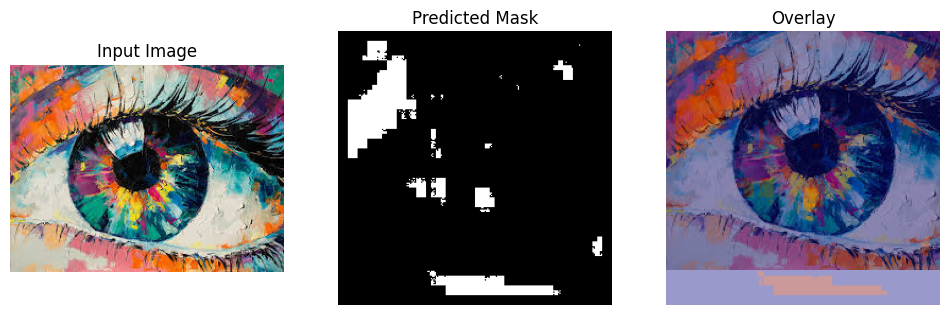

In [39]:
import matplotlib.pyplot as plt

mask = (pred > 0.7).float()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Predicted Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")

plt.imshow(image)
plt.imshow(mask, cmap="jet", alpha=0.4)

plt.axis("off")

plt.show()